In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.rcParams['figure.figsize'] = (10,6)
sns.set_theme(style='whitegrid')

## 1-Importing and cleaning data

In [4]:
acc_data = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin-1')

print(acc_data.shape)
acc_data.head()

acc_data.info()

print(acc_data.isnull().sum())

if 'Date' in acc_data.columns:
    acc_data['Date'] = pd.to_datetime(acc_data['Date'], errors='coerce')

acc_data = acc_data.drop_duplicates()

acc_data = acc_data.fillna({
    col: acc_data[col].median()
    for col in acc_data.select_dtypes(include=np.number).columns
})

print(acc_data.shape)

print(acc_data.shape)
acc_data.head()

acc_data.info()

print(acc_data.isnull().sum())

if 'Date' in acc_data.columns:
    acc_data['Date'] = pd.to_datetime(acc_data['Date'], errors='coerce')

acc_data = acc_data.drop_duplicates()

acc_data = acc_data.fillna({
    col: acc_data[col].median()
    for col in acc_data.select_dtypes(include=np.number).columns
})

print(acc_data.shape)


(4998, 17)
<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   str    
 1   Time                   3486 non-null   str    
 2   Location               4994 non-null   str    
 3   Operator               4988 non-null   str    
 4   Flight #               1329 non-null   str    
 5   Route                  4221 non-null   str    
 6   AC Type                4983 non-null   str    
 7   Registration           4724 non-null   str    
 8   cn/ln                  4330 non-null   str    
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

## 2-

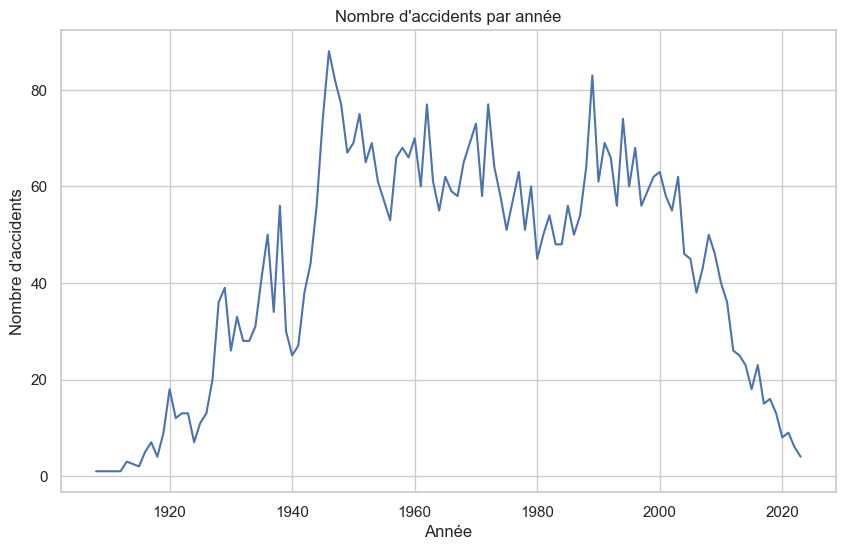

In [5]:
acc_data.describe(include='all')

if 'Deaths' in acc_data.columns:
    print('Nombre total de décès :', acc_data['Deaths'].sum())

if 'Survival_Rate' in acc_data.columns:
    print('Taux moyen de survie :', acc_data['Survival_Rate'].mean())

if 'Date' in acc_data.columns:
    accidents_par_annee = acc_data.groupby(acc_data['Date'].dt.year).size()

    plt.figure()
    accidents_par_annee.plot()
    plt.title("Nombre d'accidents par année")
    plt.xlabel("Année")
    plt.ylabel("Nombre d'accidents")
    plt.show()

## 3-Statistical analyze

In [6]:
if 'Deaths' in acc_data.columns:

    mean = acc_data['Deaths'].mean()
    median = acc_data['Deaths'].median()
    std = acc_data['Deaths'].std()

    print('Mean :', mean)
    print('Median :', median)
    print('Standard Deviation :', std)

if 'Date' in acc_data.columns and 'Deaths' in acc_data.columns:

    acc_data['Decennie'] = (acc_data['Date'].dt.year // 10) * 10

    groups = [
        g['Deaths'].dropna().values
        for _, g in acc_data.groupby('Decennie')
    ]

    if len(groups) >= 2:
        resultat = stats.f_oneway(*groups)
        print(resultat)

## 4-Visualization

In [7]:
if 'Deaths' in acc_data.columns:

    sns.histplot(acc_data['Deaths'], kde=True)
    plt.title('Distribution of deaths')
    plt.show()

if 'Region' in acc_data.columns:

    plt.figure(figsize=(12,6))
    acc_data['Region'].value_counts().plot(kind='bar')
    plt.title('Accidents by region')
    plt.xlabel('Region')
    plt.ylabel('Count')
    plt.show()

if 'Region' in acc_data.columns and 'Deaths' in acc_data.columns:

    sns.boxplot(data=acc_data, x='Region', y='Deaths')
    plt.xticks(rotation=45)
    plt.show()

## Rapport et Conclusion

### Résumé des analyses
- Décrire les tendances observées.
- Identifier les années les plus critiques.
- Comparer les régions.
- Interpréter les résultats des tests statistiques.
- Mettre en évidence les anomalies éventuelles.
### Recommandations
- Ajouter des analyses prédictives.
- Étudier les facteurs de risque.
- Construire un tableau de bord interactif.